In [1]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic

import cv2
from PIL import Image


In [58]:
def show_img(img, title=None, cmap=None, bgr=False, title_size=8, ax=None, figsize=None):
    if 'torch' in sys.modules and torch.is_tensor(img):
        if len(img.shape)==2: img= img.unsqueeze(dim=0)
        img = img.permute(1, 2, 0)
    fig = None
    if ax is None:
        fig = plt.figure(figsize=figsize)#, dpi=72)
        ax = axs = fig.subplots(1, 1)
    ax.axis('off')
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title: ax.set_title(title, **STYLE_PLOT_TITLE)
    if cmap is None:
        cmap = 'gray' if len(img.shape)==2 else None
    if bgr and len(img.shape)==3 and img.shape[2]==3:
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img, cmap=cmap)
    if fig is not None:
        plt.show()
    return ax

#imgs: [array(H,W)[:int32]]
def show_imgs(imgs, titles=None, cmap=None, ncols=None, nrows=None, bgr=False, title_size=4, figsize=None, pad=0):
    if ncols==None:
        if nrows==None: ncols=1
        else: ncols=int(len(imgs)/nrows) + (len(imgs) % nrows > 0)
    if isinstance(imgs, list):
        imgs = np.array(imgs)
    if nrows==None:
        nrows=int(imgs.shape[0]/ncols) + (imgs.shape[0] % ncols > 0)
    fig = plt.figure(figsize=figsize) #, dpi=72)
    axs = fig.subplots(nrows, ncols)
    axs = axs.flatten()
    plt.subplots_adjust(top=1-pad, bottom=0+pad, left=0+pad, right=1-pad, wspace=pad, hspace=pad) 
    #print('!!',nrows, ncols, axs)
    for ax in axs:
        ax.axis('off')
        ax.set_yticks([])
        ax.set_yticklabels([])
        ax.tick_params(left=False)
    for i in range(imgs.shape[0]):
        img = imgs[i] 
        if cmap is None:
            cmap_ = 'gray' if len(img.shape)==2 else None
        else:
            cmap_ = cmap[i] if isinstance(cmap, list) else cmap
        if bgr and len(img.shape)==3 and img.shape[2]==3:
            img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img, cmap=cmap_)
        STYLE_PLOT_TITLE= {'fontsize': title_size }
        if titles and i<len(titles):
            axs[i].set_title(str(titles[i]), **STYLE_PLOT_TITLE)
    plt.show()
    return axs

    
def cv_bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [3]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data        # shape (70000, 784)
y = mnist.target     # labels as strings



(70000, 784) (70000,)
(70000, 28, 28) (70000,)


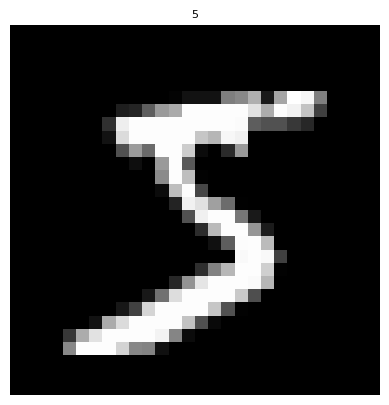

<Axes: title={'center': '5'}>

In [40]:
print(X.shape, y.shape)
y_ = y.astype(int) # Convert labels to int
X_ = X.reshape(-1, 28, 28)
print(X_.shape, y.shape)
show_img(X_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)



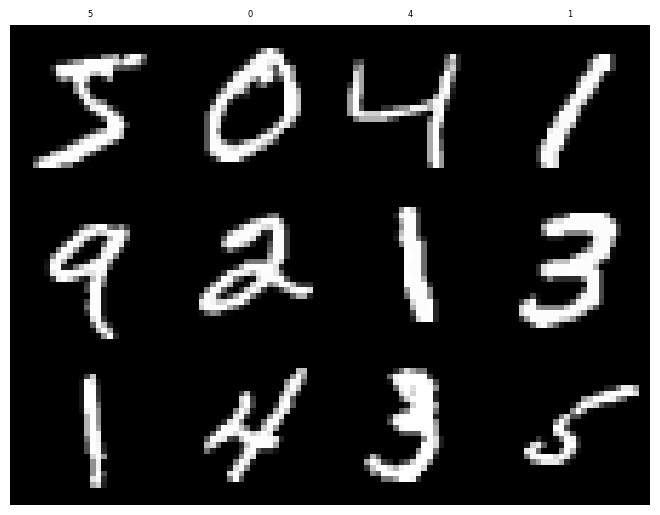

array([<Axes: title={'center': '5'}>, <Axes: title={'center': '0'}>,
       <Axes: title={'center': '4'}>, <Axes: title={'center': '1'}>,
       <Axes: title={'center': '9'}>, <Axes: title={'center': '2'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '3'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '4'}>,
       <Axes: title={'center': '3'}>, <Axes: title={'center': '5'}>],
      dtype=object)

In [5]:
show_imgs(X_[:12], titles=y[:12].tolist(), ncols=4, nrows=None, title_size=6, figsize=None, pad=0)


(70000, 28, 28)
(3, 3, 9, 9)
(3, 3, 9, 9) (9, 9, 9) (9, 81)


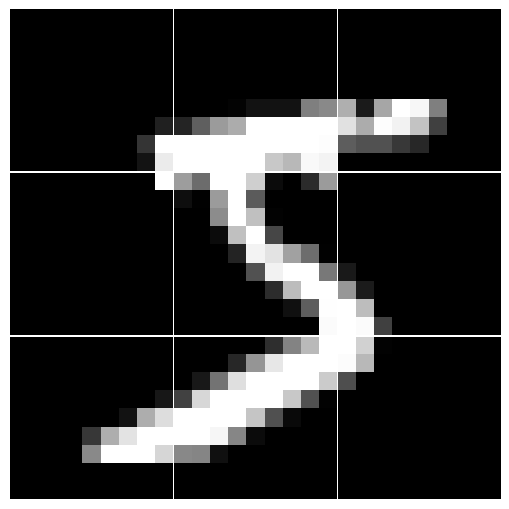

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

def tiles(a, K, S):
    tiles = sliding_window_view(a, (K, K))
    return tiles[::S, ::S]

print(X_.shape)

Xs=tiles(X_[0], K=9, S=9)
print(Xs.shape)

Xs_ = Xs.reshape(-1, *Xs.shape[2:])
Xs__ = Xs_.reshape(Xs_.shape[0], -1)
print(Xs.shape, Xs_.shape, Xs__.shape)
show_imgs(Xs_, titles=None, ncols=Xs.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)





(784,) int64
(784, 784)


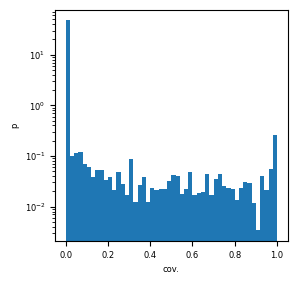

In [122]:
Xf = X.astype(float)/255
print(X[0].shape, X.dtype)
C = np.outer(Xf[0], Xf[0])
print(C.shape)
#for T in np.linspace(0, .1, num=22):
#    print(T, C.shape[0]*C.shape[0], np.sum(C>=T))

def hist_cov(C, title=None, title_size=6,  axs=None, axi=0, figsize=(1*3,1*3)):
    fig = None
    if axs is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        axs = fig.subplots(1, 1)
        ax = axs
    else:
        ax = axs[axi]
    STYLE_PLOT_TITLE= {'fontsize': title_size }
    if title:
        ax.set_title(title, **STYLE_PLOT_TITLE)
    C_ = C.flatten()
    ax.hist(C_, bins=50, density=True)
    ax.set_xlabel("cov.", fontsize=6)
    ax.set_ylabel("p", fontsize=6)
    ax.set_yscale("log")
    ax.tick_params(axis='both', labelsize=6)
    if fig is not None:
        plt.show()

hist_cov(C)


(784,) (784, 784)
(16, 784)
(16, 28, 28)


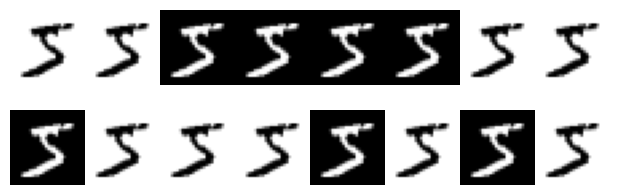

In [9]:
m = np.zeros(C.shape[0]) + .5
print(m.shape, C.shape)
x = np.random.multivariate_normal(m, C*20, 16)
print(x.shape)
x_ = x.reshape(-1, 28, 28)
print(x_.shape)
x__ = x_*255
#show_img(x__[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
_=show_imgs(x__, titles=y[:0].tolist(), ncols=8, nrows=None, title_size=6, figsize=(6*1, 2*1), pad=0)
#print(x_[0][14])
#print(x_[1][14])
#print(x__[0][14])
#print(x__[1][14])


(70000, 784) (70000, 28, 28) (70000,)


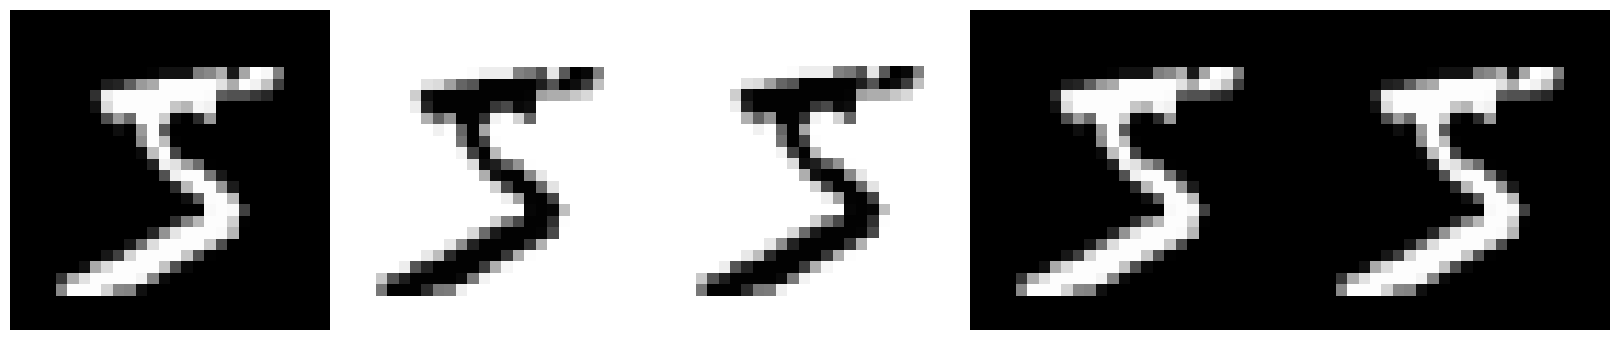

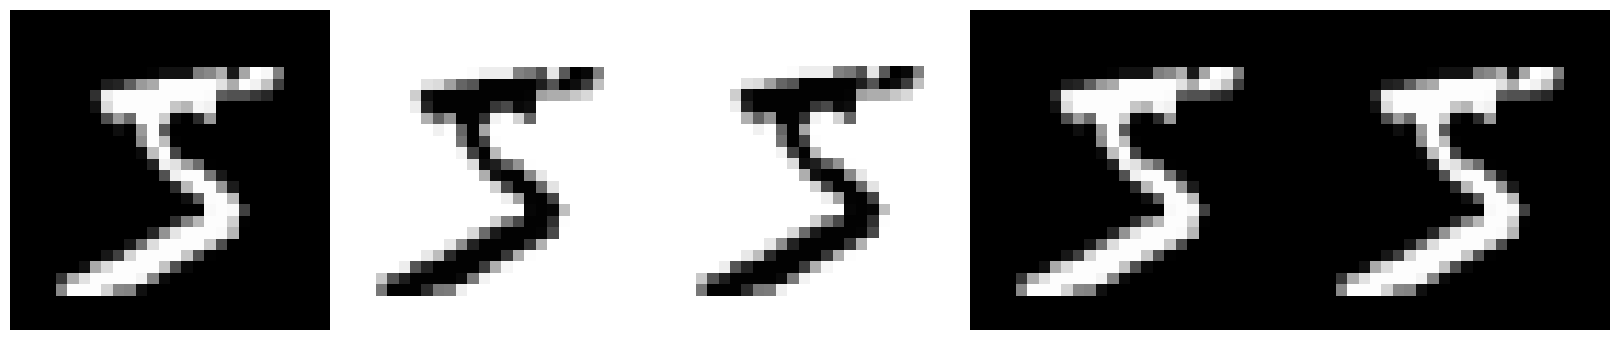

[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.31764706 0.94117647 0.99215686 0.99215686 0.46666667
 0.09803922 0.         0.         0.         0.         0.
 0.         0.         0.         0.        ]
[  0   0   0   0   0   0   0   0   0   0   0   0   0  81 240 253 253 119
  25   0   0   0   0   0   0   0   0   0]
0 [ 0.50000067  0.49999984  0.49999984  0.50000008  0.49999985  0.50000049
  0.50000077  0.49999979  0.50000026  0.5000002   0.49999974  0.49999973
  0.4999997  -1.72090663 -6.08046701 -6.4369084  -6.43690841 -2.76281441
 -0.18546487  0.49999903  0.49999929  0.49999952  0.50000042  0.49999998
  0.50000009  0.50000008  0.49999999  0.49999956]
0 [  127.50016963   127.49995958   127.49995797   127.50002142
   127.49996127   127.50012603   127.50019721   127.49994702
   127.50006539   127.50004974   127.49993493   127.49993214
   127.49992327  -438.8311902  -1550.51908869 -1641.41164195
 -164

In [10]:
Xf_ = Xf.reshape(-1, 28, 28)
print(Xf.shape, Xf_.shape, y.shape)
_=show_imgs([Xf_[0], x_[0], x_[1], x_[2],x_[3]], ncols=5, figsize=(4*4, 1*4))
_=show_imgs([X_[0], x__[0], x__[1], x__[2],x__[3]], ncols=5, figsize=(4*4, 1*4))
print(Xf_[0,14])
print(X_[0,14])
for i in range(0, 2):
    print(i, x_[i,14])
    print(i, x__[i,14])



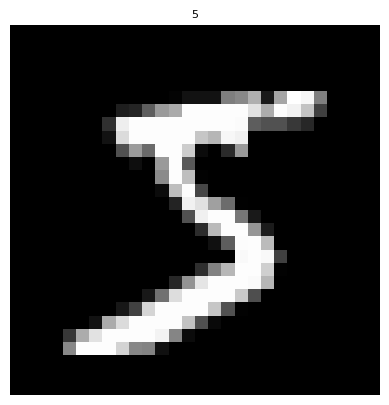

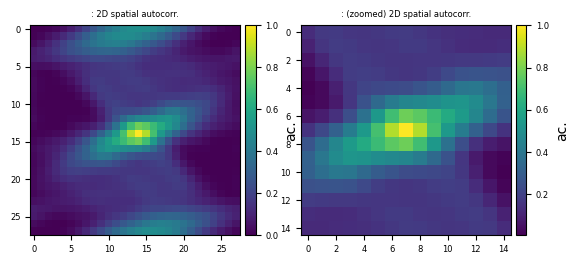

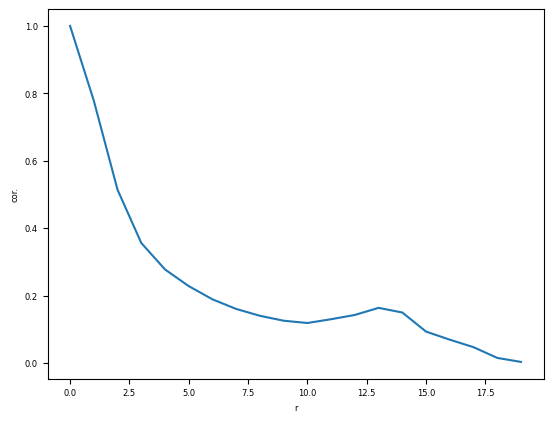

In [91]:
def autocorr2d_fft(img, normalize=True):
    F = np.fft.fft2(img)
    S = np.abs(F)**2
    C = np.fft.ifft2(S).real
    ac2d = np.fft.fftshift(C)  # center at zero displacement
    if normalize:
        ac2d = ac2d/ac2d[img.shape[0]//2, img.shape[1]//2]
    return ac2d

def autocorr_radial_(C):
    ny, nx = C.shape
    y, x = np.indices((ny, nx))
    cy, cx = ny // 2, nx // 2
    r = np.sqrt((x - cx)**2 + (y - cy)**2).astype(int)
    tbin = np.bincount(r.ravel(), C.ravel())
    nr = np.bincount(r.ravel())
    acr = tbin / nr
    return acr

def autocorr_radial(img, normalize=True):
    ac2d = autocorr2d_fft(img, normalize=False)
    acr = autocorr_radial_(ac2d)
    if normalize:
        acr /= acr[0]
    return acr


def autocorr_radial2(f, max_r):
    h, w = f.shape
    C = np.zeros(max_r)
    N = np.zeros(max_r)

    for y in range(h):
        for x in range(w):
            for dy in range(-max_r, max_r+1):
                for dx in range(-max_r, max_r+1):
                    r = int(np.sqrt(dx*dx + dy*dy))
                    if r < max_r:
                        y2, x2 = y+dy, x+dx
                        if 0 <= y2 < h and 0 <= x2 < w:
                            C[r] += f[y, x] * f[y2, x2]
                            N[r] += 1
    return C / N

from mpl_toolkits.axes_grid1 import make_axes_locatable

def show_autocorr2d(ac2d, title='', axs=None, axi=0, figsize=None):
    fig = None
    if axs is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        axs = fig.subplots(1, 2)
    ax0 = axs[axi]
    im0 = ax0.imshow(ac2d)
    div0 = make_axes_locatable(ax0)
    cax0 = div0.append_axes('right', size='5%', pad=0.05)
    cbar0 = ax0.get_figure().colorbar(im0, cax=cax0, orientation='vertical', label="ac.")
    cbar0.ax.tick_params(labelsize=6)
    ax0.set_title(f"{title}: 2D spatial autocorr.", fontsize=6)
    ax0.tick_params(axis='both', labelsize=6)
    ny, nx = ac2d.shape
    cy, cx = ny // 2, nx // 2
    R = min(ny, nx)//4  # radius in pixels
    ac2d_ = ac2d[cy-R:cy+R+1, cx-R:cx+R+1]
    ax1 = axs[axi+1]
    im1 = ax1.imshow(ac2d_)
    div1 = make_axes_locatable(ax1)
    cax1 = div1.append_axes('right', size='5%', pad=0.05)
    cbar1 = ax1.get_figure().colorbar(im1, cax=cax1, orientation='vertical', label="ac.")
    cbar1.ax.tick_params(labelsize=6)
    ax1.set_title(f"{title}: (zoomed) 2D spatial autocorr.", fontsize=6)
    ax1.tick_params(axis='both', labelsize=6)
    if fig is not None:
        plt.show()
    
def compute_show_autocorr2d(img, normalize=True, title='', axs=None, axi=0, figsize=None):
    ac2d = autocorr2d_fft(img, normalize=normalize)
    show_autocorr2d(ac2d, title=title, axs=axs, axi=axi, figsize=figsize)
    return ac2d

def show_autocorr_radial(acr, title=None, title_size=6, ax=None, figsize=None):
    fig = None
    if ax is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        ax = axs = fig.subplots(1, 1)
    #print(acr)
    if title:
        STYLE_PLOT_TITLE= {'fontsize': title_size }
        ax.set_title(title, **STYLE_PLOT_TITLE)
    ax.plot(acr)
    ax.set_xlabel("r", fontsize=6)
    ax.set_ylabel("cor.", fontsize=6)
    ax.tick_params(axis='both', labelsize=6)
    if fig is not None:
        plt.show()
    
def compute_show_autocorr_radial(img, title=None, title_size=6, ax=None, figsize=None):
    acr = autocorr_radial(img)
    #acr2 = autocorr_radial2(img, img.shape[1])
    show_autocorr_radial(acr, title=title, title_size=title_size, ax=ax, figsize=figsize)

show_img(Xf_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
ac2d = autocorr2d_fft(Xf_[0], normalize=True)
show_autocorr2d(ac2d)
acr = autocorr_radial(Xf_[0])
show_autocorr_radial(acr)
#acr2 = autocorr_radial2(Xf_[0], Xf_.shape[1])
#show_autocorr_radial(acr2)

#print(Xf_[0,14])
#print(ac2d.shape)
#print(acr.shape)
#print(acr2.shape)
#print(ac2d[14])
#print(acr)
#print(acr2)


In [ ]:
def img_cov(a, rescale=True):
    if rescale:
        a = a.copy().astype(float)/255
    a_ = a.flatten()
    A = np.outer(a_, a_)
    return A 

def show_img_cov(C, rescale=False, title=None, title_size=6, ax=None, figsize=None):
    if rescale:
        C = (C*255).astype(int)
    show_img(C, title=title, title_size=title_size, ax=ax, figsize=figsize)

def compute_show_img_cov(img, rescale=False, title=None, title_size=6, ax=None, figsize=None):
    C = img_cov(img, rescale=rescale)
    show_img_cov(C, title=title, title_size=title_size, ax=ax, figsize=figsize)

    

In [130]:
def xshow_img(img, title=f'', cmap=None, bgr=False, title_size=8, axs=None, figsize=(6*3, 1*3)):
    fig = None
    if axs is None:
        fig = plt.figure(figsize=figsize) #, dpi=72)
        axs = fig.subplots(1, 6)
    im0 = show_img(img, title=title, cmap=cmap, bgr=bgr, title_size=title_size, ax=axs[0])
    hist_cov(img, title=f'{i}', axs=axs, axi=1)
    compute_show_autocorr2d(img, title=f'{i}', axs=axs, axi=2)
    compute_show_autocorr_radial(img, title=f'{i}', title_size=6, ax=axs[4])
    compute_show_img_cov(img, title=f'{i}: cov', ax=axs[5])
    if fig is not None:
        plt.show()


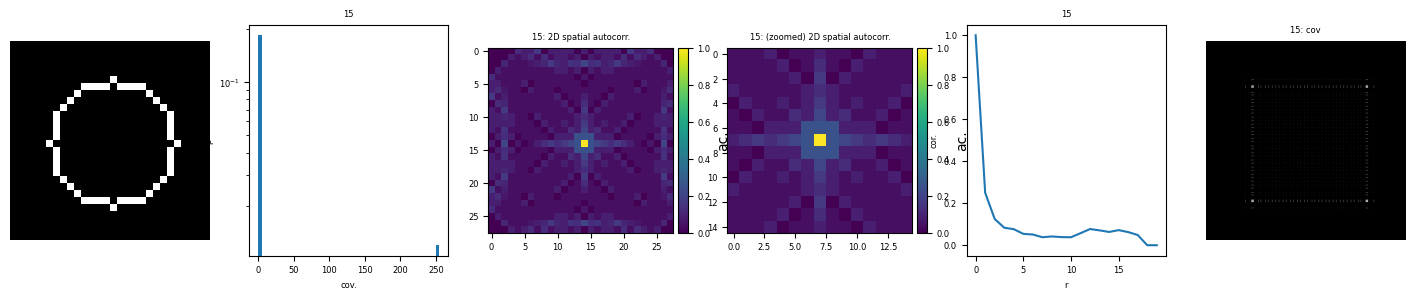

In [131]:
a = np.zeros((28,28))
w,h = a.shape[1],a.shape[0]
color=(255,255,255)
cv2.circle(a,center=(w//2,h//2), radius=2*min(w, h)//6,color=color, thickness=1)

xshow_img(a)

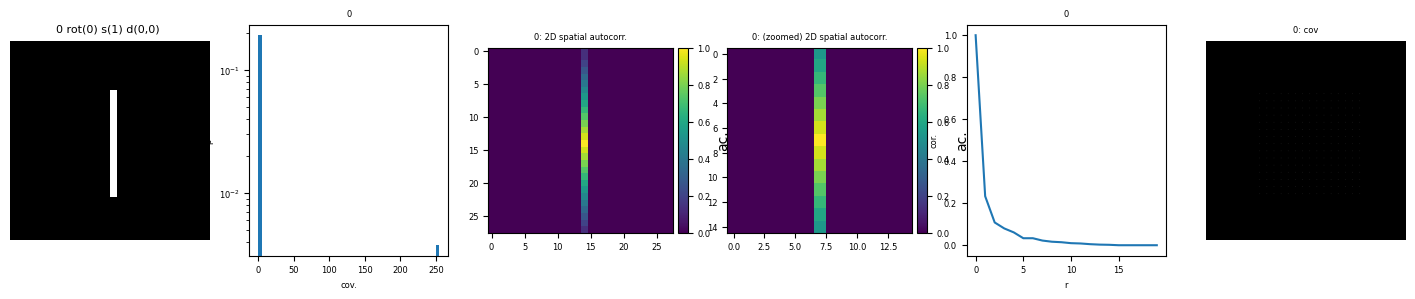

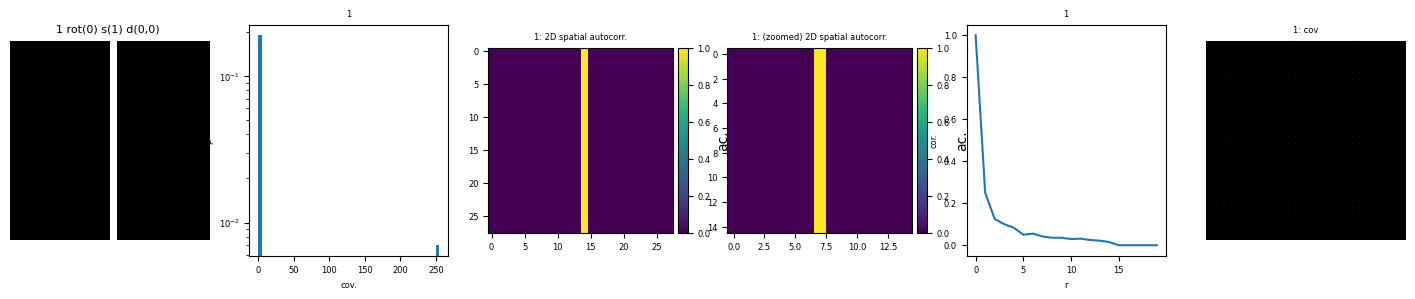

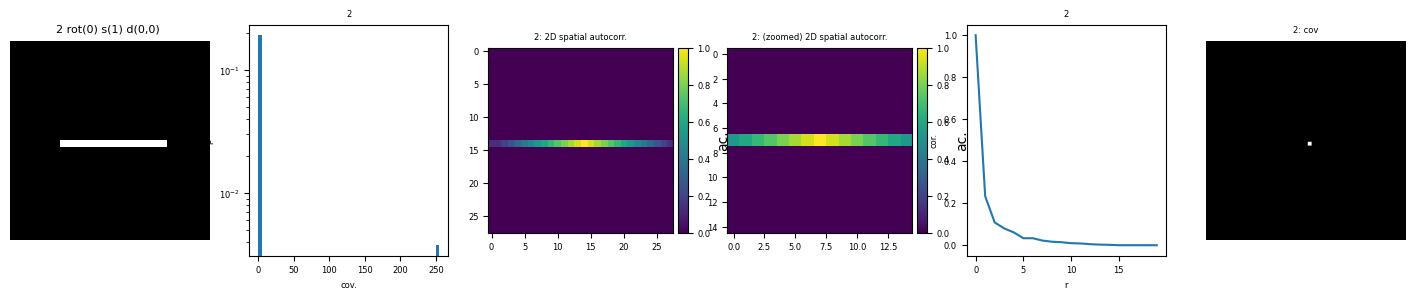

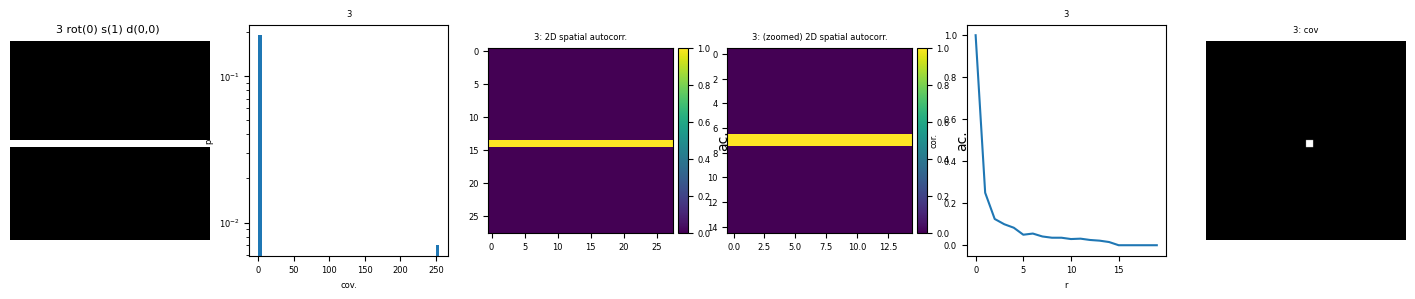

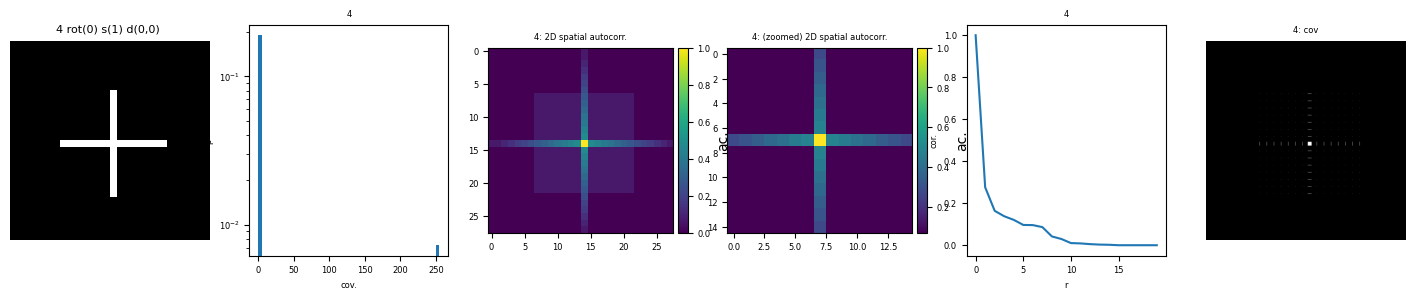

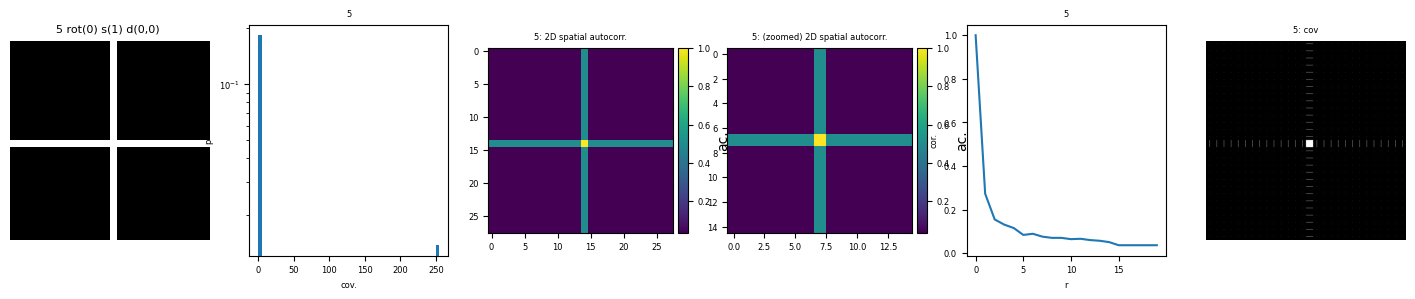

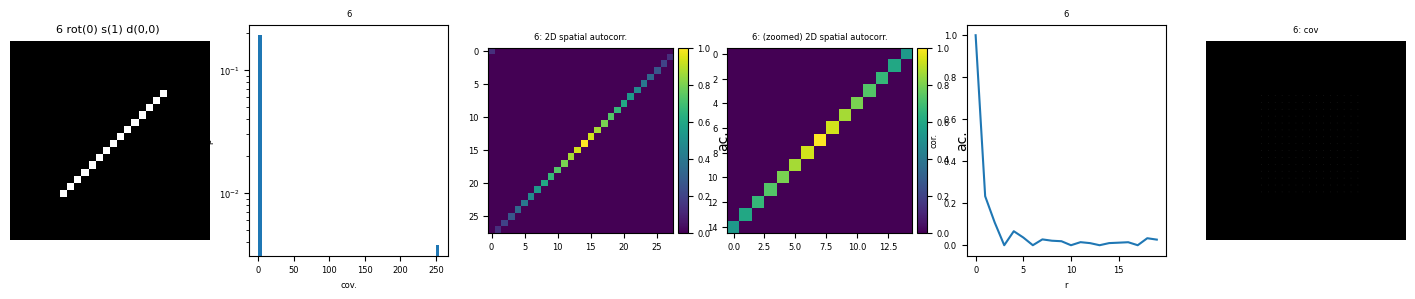

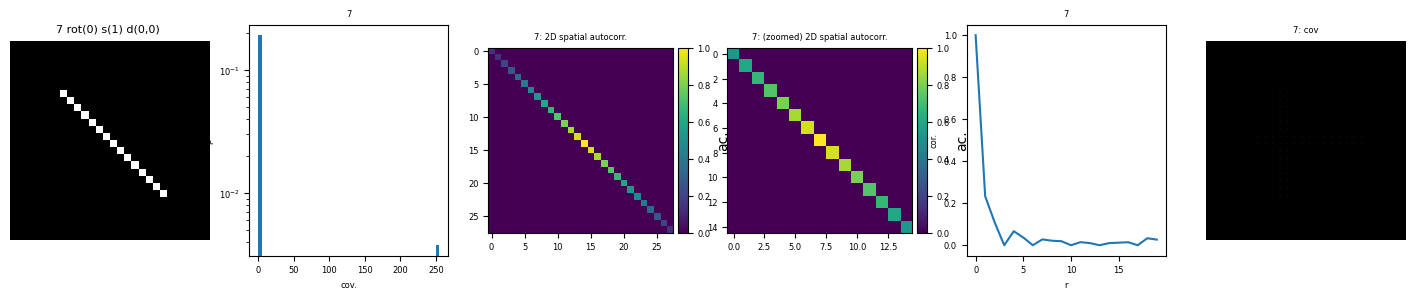

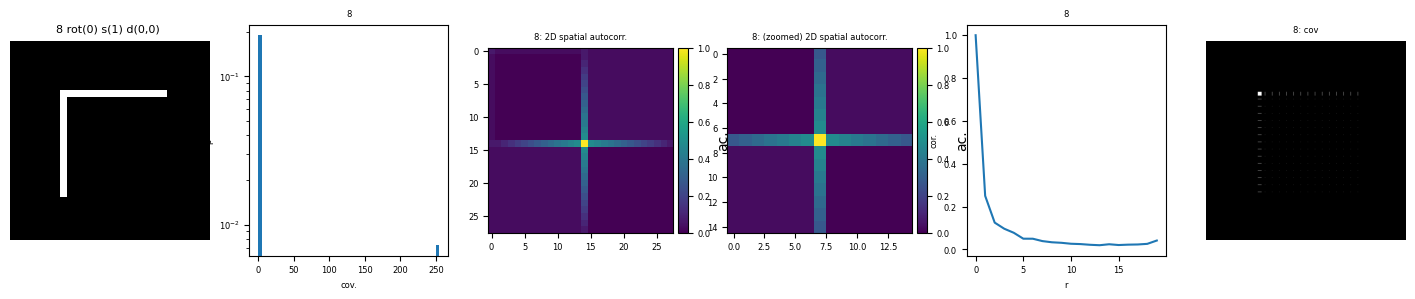

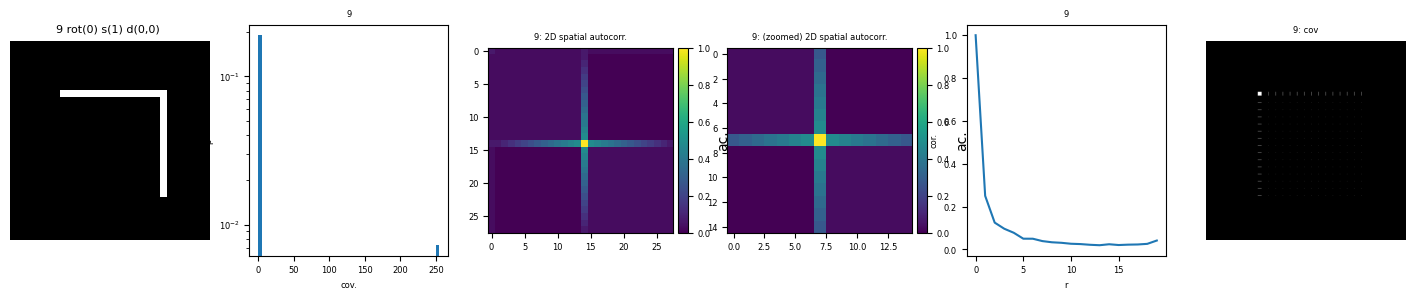

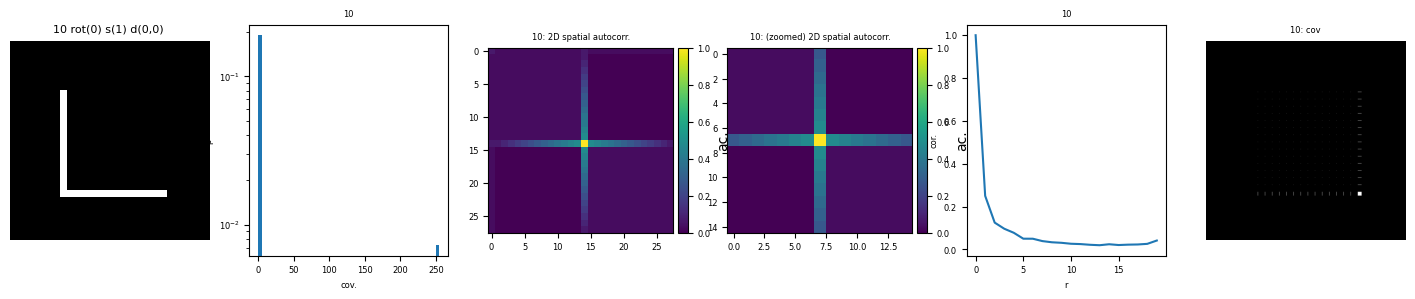

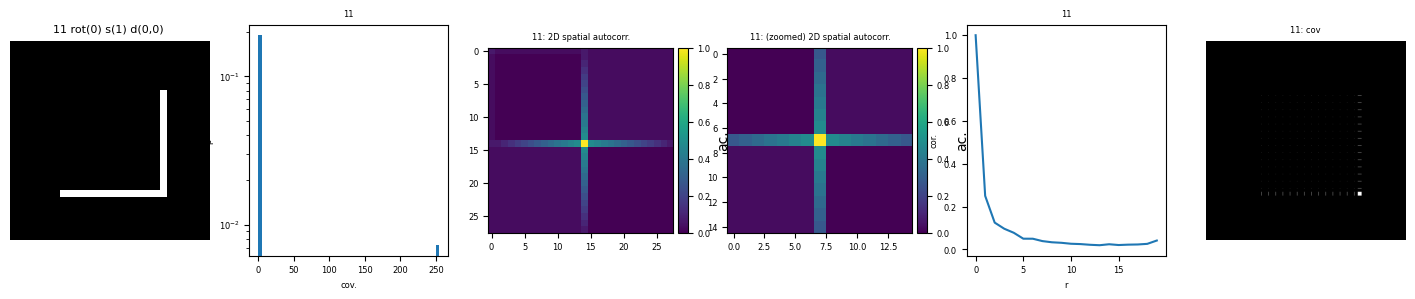

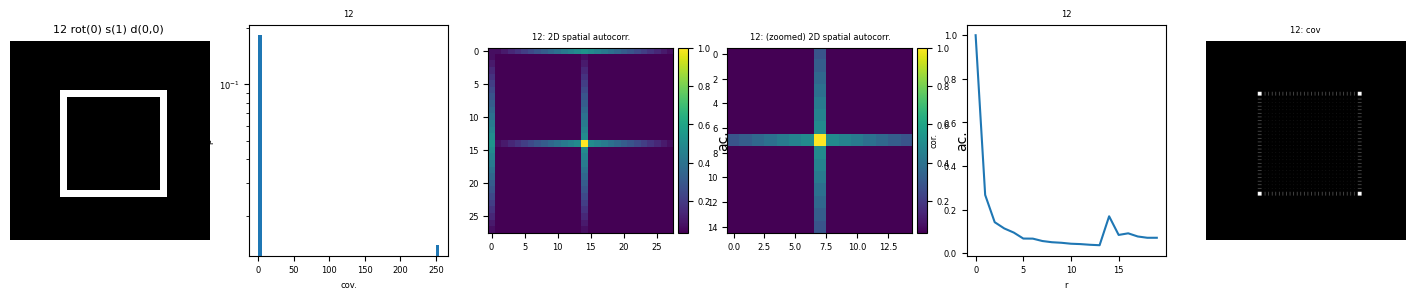

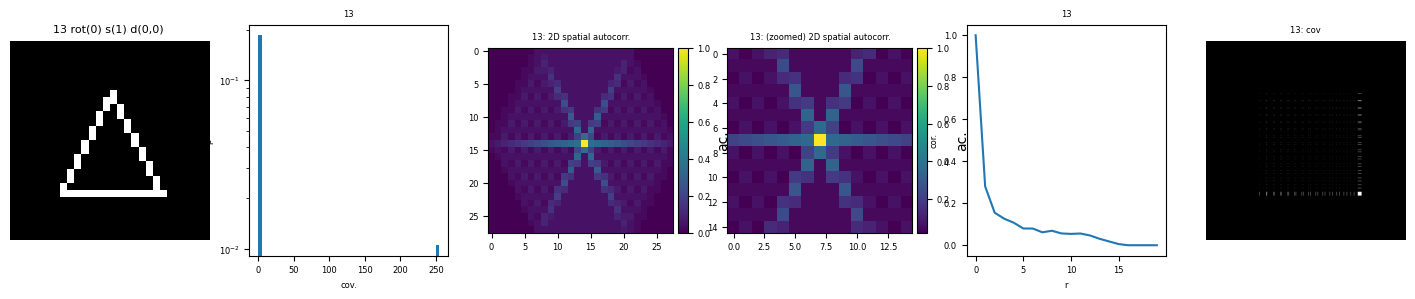

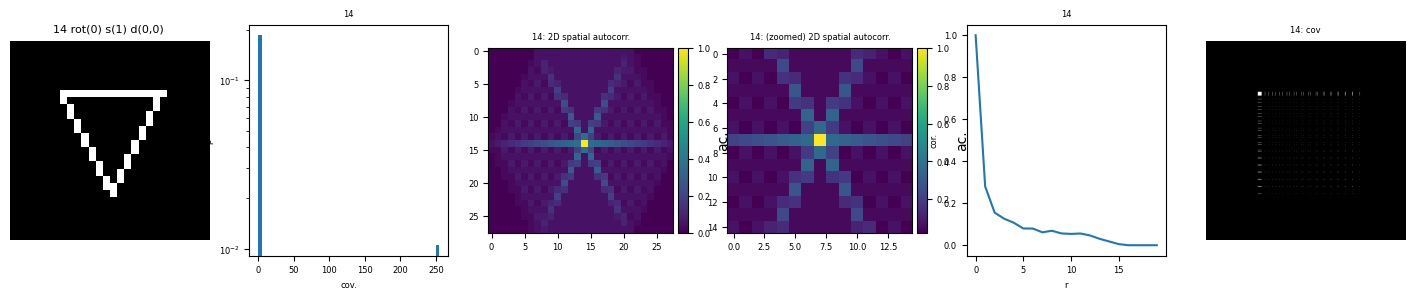

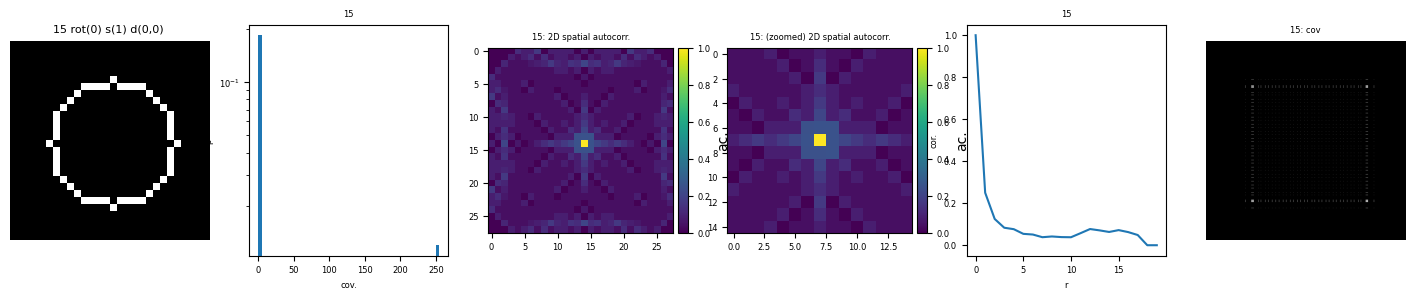

In [132]:
def make_glyph(n=0, shape=(28,28), color=(255,255,255), lw=1, dx=0, dy=0, sx=1, sy=1, rot=0):
    a = np.zeros((28,28))
    w,h = a.shape[1],a.shape[0]
    if n==0: #GLYPH_VSLINE
        cv2.line(a,(w//2,h//4),(w//2,h//4*3),color,lw)
    elif n==1: #GLYPH_VLINE
        cv2.line(a,(w//2,0),(w//2,h),color,lw)
    elif n==2: #GLYPH_HSLINE
        cv2.line(a,(w//4,h//2),(w//4*3,h//2),color,lw)
    elif n==3: #GLYPH_HLINE
        cv2.line(a,(0,h//2),(w,h//2),color,lw)
    elif n==4: #GLYPH_PLUS
        cv2.line(a,(w//2,h//4),(w//2,h//4*3),color,lw)
        cv2.line(a,(w//4,h//2),(w//4*3,h//2),color,lw)
    elif n==5: #GLYPH_CROSS
        cv2.line(a,(w//2,0),(w//2,h),color,lw)
        cv2.line(a,(0,h//2),(w,h//2),color,lw)
    elif n==6: #GLYPH_SLASH
        cv2.line(a,(3*w//4,h//4),(w//4,3*h//4),color,lw)
    elif n==7: #GLYPH_BACKSLASH
        cv2.line(a,(w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==8: #GLYPH_CORNER_TL
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//4,3*h//4),color,lw)
    elif n==9: #GLYPH_CORNER_TR
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==10: #GLYPH_CORNER_BL
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//4,3*h//4),color,lw)
    elif n==11: #GLYPH_CORNER_BR
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==12: #GLYPH_SQUARE
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//4,3*h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(3*w//4,3*h//4),color,lw)
    elif n==13: #GLYPH_TRIANGLE
        cv2.line(a,(w//4,3*h//4),(3*w//4,3*h//4),color,lw)
        cv2.line(a,(w//4,3*h//4),(w//2,h//4),color,lw)
        cv2.line(a,(3*w//4,3*h//4),(w//2,h//4),color,lw)
    elif n==14: #GLYPH_INV_TRIANGLE
        cv2.line(a,(w//4,h//4),(3*w//4,h//4),color,lw)
        cv2.line(a,(w//4,h//4),(w//2,3*h//4),color,lw)
        cv2.line(a,(3*w//4,h//4),(w//2,3*h//4),color,lw)
    elif n==15: #GLYPH_CIRC
        cv2.circle(a,(w//2,h//2), 2*min(w, h)//6, color, lw)
    if dx!=0 or dy!=0:
        dxy = np.float32([[1, 0, dx], [0, 1, dy]])
        a = cv2.warpAffine(a, dxy, (w, h))
    if sx!=1 or sy!=1:
        a = cv2.resize(a, None, fx=sx, fy=sy, interpolation=cv2.INTER_AREA) #| cv2.INTER_CUBIC | INTER_LINEAR
    if rot!=0:
        rm = cv2.getRotationMatrix2D((w//2,h//2), rot, 1.0)
        a = cv2.warpAffine(a, rm, (w, h))
    return a

def show_glyph_txs(i, rot=True, sxy=True, dx=True, dy=True):
    def _values(x, value0, value1):
        if isinstance(x, list):
            return x
        if isinstance(x, bool):
            return value1 if x else value0
        return [x]
    rot = _values(rot, [0], [0, -20, +20])
    sxy = _values(sxy, [1], [1, 1.5])
    dx = _values(dx, [0], [0, 10])
    dy = _values(dy, [0], [0, 10])
    for rot_ in rot:
        for sxy_ in sxy:
            for dx_ in dx:
                for dy_ in dy:
                    a = make_glyph(i, dx=dx_, dy=dy_, sx= sxy_, sy=sxy_, rot=rot_)
                    xshow_img(a, title=f'{i} rot({rot_}) s({sxy_}) d({dx_},{dy_}) ', title_size=8)

for i in range(0, 16):
    show_glyph_txs(i, rot=False, sxy=False, dx=False, dy=False)
    


(784, 784)
3136.0 1.0


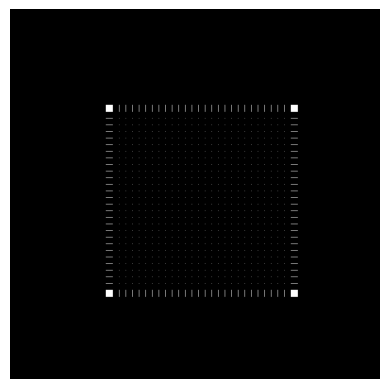

In [ ]:

for i in range(0, 16):
    #show_glyph_txs(i, rot=False, sxy=False, dx=False, dy=False)
    a = make_glyph(12, dx=0, dy=0, sx= 1, sy=1, rot=0)
    #print(A.shape)
    #print(A.sum(), A.max())
    #A = img_cov(a)
    compute_show_img_cov(A)

#print(A_.nonzero())
#print(A_[210])
#self.Zp = np.outer(zy, zs)
#self.Zn = np.outer(zy, 1-zs)

In [ ]:
A=Xs__
A_ = A[:, :, None] * A[:, None, :]
print(A.shape, Xs__.shape)

show_imgs(A_, titles=None, ncols=A_.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)
